In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as colors
from matplotlib.colors import Normalize

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from kneed import KneeLocator

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KernelDensity
from sklearn.metrics import silhouette_score

from scipy.stats import gaussian_kde


### Explore the data

The data is supposed to have the following features:

n (trajectory id), x, y (coordinates of the trajectory in the real space), h_1, h_2, ..., h_16 (coordinates of the trajectories in the 16d latent space), U_1, U_2 (coordinates of the trajectory in the 2d UMAP projection of the 16d latent space), D (diffusivity), log_D,n_points

In [34]:
def print_data(path):
    """
    print_data function.
    print the data and the name of the columns
    """
    df = pd.read_csv(path)
    print(df.describe())
    print(df.columns)

print_data("gratin_results_for_n2_+myoIb_1_trackedPar.csv")



        Unnamed: 0         p_fBM          p_LW        p_sBM          p_OU  \
count  3056.000000  3.056000e+03  3.056000e+03  3056.000000  3.056000e+03   
mean   1658.167212  2.369713e-01  6.522022e-02     0.271336  1.699996e-01   
std     997.136934  2.065055e-01  1.629155e-01     0.222219  1.732847e-01   
min       1.000000  3.868509e-07  6.113031e-10     0.000001  1.927055e-07   
25%     790.750000  6.042058e-02  3.321692e-05     0.104213  1.771357e-02   
50%    1623.500000  2.012285e-01  2.331435e-04     0.233026  1.149562e-01   
75%    2498.250000  3.329344e-01  8.058349e-03     0.375514  2.860529e-01   
max    3501.000000  9.757929e-01  9.831060e-01     0.989935  8.039599e-01   

            p_CTRW        alpha       length          U_1          U_2  ...  \
count  3056.000000  3056.000000  3056.000000  3056.000000  3056.000000  ...   
mean      0.256473     1.022417   107.392997    -0.271600    -1.640351  ...   
std       0.381495     0.313057   143.042721     2.767215     4.61611

In [35]:
def selecting_columns_of_interest(tab, column_names : [str]):
    return tab[column_names].copy()

tab=pd.read_csv("gratin_results_for_n2_+myoIb_1_trackedPar.csv")
print(tab.columns)
tab2=selecting_columns_of_interest(tab, [ 'best_model', 'p_fBM', 'p_LW', 'p_sBM', 'p_OU', 'p_CTRW',
       'alpha', 'length', 'U_1', 'U_2', 'n'])

tab3=selecting_columns_of_interest(tab,['best_model','h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16', 'n'])
print(tab2.columns)

def formating_data(tab, remove_columns, replace_colum_name): 
    """    
    replace_colum_name is a dictionnary 
    replace_colum_name = {"old_name_colum1": "new_name_colum1",...}
    """
    
    # Remove rows with missing values
    tab.dropna(inplace=True)

    # Check which columns exist before dropping
    existing_cols_to_remove = [col for col in remove_columns if col in tab.columns]

    tab.drop(columns=existing_cols_to_remove, inplace=True)

    # Rename columns
    tab.rename(columns=replace_colum_name, inplace=True)

    return tab

print(formating_data(tab,['U_1'],{'U_2':'alpha'}).describe())


Index(['Unnamed: 0', 'best_model', 'p_fBM', 'p_LW', 'p_sBM', 'p_OU', 'p_CTRW',
       'alpha', 'length', 'U_1', 'U_2', 'h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16', 'n'],
      dtype='object')
Index(['best_model', 'p_fBM', 'p_LW', 'p_sBM', 'p_OU', 'p_CTRW', 'alpha',
       'length', 'U_1', 'U_2', 'n'],
      dtype='object')
        Unnamed: 0         p_fBM          p_LW        p_sBM          p_OU  \
count  3056.000000  3.056000e+03  3.056000e+03  3056.000000  3.056000e+03   
mean   1658.167212  2.369713e-01  6.522022e-02     0.271336  1.699996e-01   
std     997.136934  2.065055e-01  1.629155e-01     0.222219  1.732847e-01   
min       1.000000  3.868509e-07  6.113031e-10     0.000001  1.927055e-07   
25%     790.750000  6.042058e-02  3.321692e-05     0.104213  1.771357e-02   
50%    1623.500000  2.012285e-01  2.331435e-04     0.233026  1.149562e-01   
75%    2498.250000  3.329344e-01  8.058349e-03  

### Using Facet Grid

FacetGrid is a powerful tool from Seaborn that allows you to create a grid of plots based on the values of one or more categorical variables. By splitting the data into subplots, each corresponding to a subset defined by specific parameter values, it becomes easier to observe patterns, trends, or anomalies that may not be visible in aggregated views.


KeyError: 'facet_col'

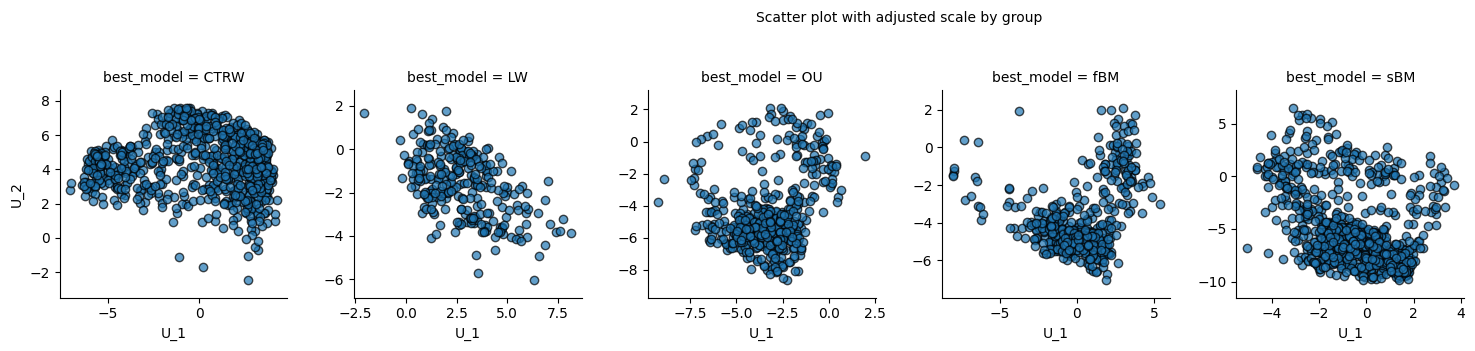

In [36]:

def plot_facet_scatter_with_scaled_axes(data, x_col, y_col, facet_col, margin_x=0.05, margin_y=0.1):
    """
Displays a scatter plot in a FacetGrid with automatic adjustment of the X and Y axes.

**Args:**
- `data` (pd.DataFrame): DataFrame containing the data.  
- `x_col` (str): Name of the column for the X-axis.  
- `y_col` (str): Name of the column for the Y-axis.  
- `facet_col` (str): Name of the column used to group the subplots.  
- `margin_x` (float): Relative margin for the X-axis (e.g., 0.05 = 5%).  
- `margin_y` (float): Relative margin for the Y-axis (e.g., 0.1 = 10%).
 """
    # Create FacetGrid
    g = sns.FacetGrid(data, col=facet_col, sharex=False, sharey=False)  # Disable axis sharing for independent scaling
    
    # Plotting function
    def facet_scatter(x, y, color, **kwargs):
        plt.scatter(x, y, color=color, alpha=0.7, edgecolor="black")

        # Auto-adjust X axis
        x_min, x_max = min(x), max(x)
        x_margin = (x_max - x_min) * margin_x
        plt.xlim(x_min - x_margin, x_max + x_margin)

        # Auto-adjust Y axis
        y_min, y_max = min(y), max(y)
        y_margin = (y_max - y_min) * margin_y
        plt.ylim(y_min - y_margin, y_max + y_margin)

    # Apply the function to each facet
    g.map(facet_scatter, x_col, y_col)

    # Add global labels
    g.set_axis_labels(x_col, y_col)
    g.add_legend(title="Scatter plot with adjusted scale by group")
    g.legend.set_bbox_to_anchor((0.5, 1.1))
    g.legend.set_loc("center")

    g.set_titles(col_template='legend : {facet_col}') 
    
    plt.show()

plot_facet_scatter_with_scaled_axes(tab2,'U_1','U_2','best_model')

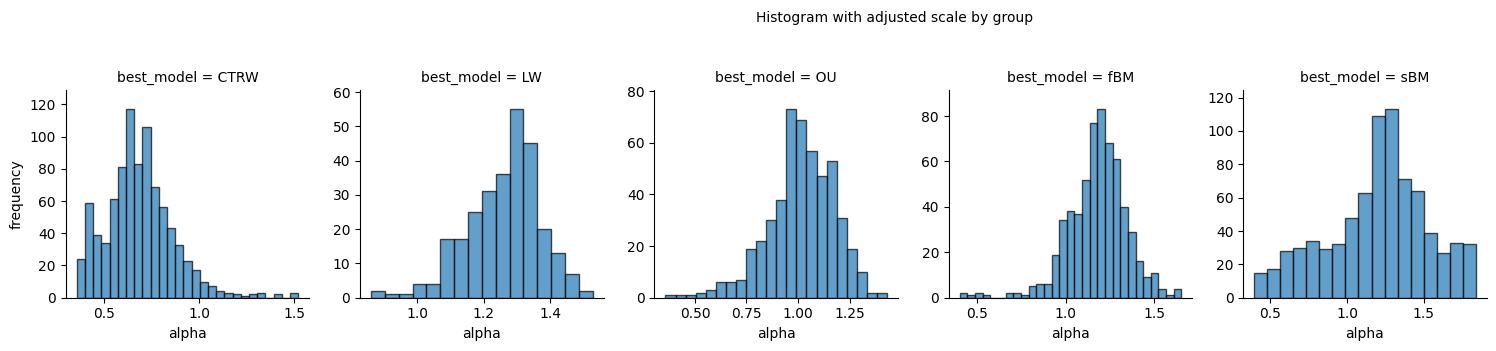

In [ ]:

def plot_facet_histogram_with_scaled_axes(data, x_col, facet_col, bins='auto', margin_x=0.05, margin_y=0.1):
    """
    
Displays a scatter plot in a FacetGrid with automatic adjustment of the X and Y axes.

**Args:**
- `data` (pd.DataFrame): DataFrame containing the data.  
- `x_col` (str): Name of the column for the X-axis.  
- 'bins' (int ou str): Number of bins of bins calcul mode ('auto', 'sturges', etc.).
- `margin_x` (float): Relative margin for the X-axis (e.g., 0.05 = 5%).  
- `margin_y` (float): Relative margin for the Y-axis (e.g., 0.1 = 10%).
    """
    # Create FacetGrid
    g = sns.FacetGrid(data, col=facet_col, sharex=False, sharey=False)  # Disable axis sharing for independent scaling
    
    # Plotting function
    def facet_hist(x, color, **kwargs):
        counts, bin_edges, _ = plt.hist(x, bins=bins, alpha=0.7, edgecolor="black", color=color)

        # Auto-adjust X axis
        x_min, x_max = bin_edges[0], bin_edges[-1]
        x_margin = (x_max - x_min) * margin_x
        plt.xlim(x_min - x_margin, x_max + x_margin)

        # Auto-adjust Y axis
        y_max = max(counts)
        y_margin = y_max * margin_y
        plt.ylim(0, y_max + y_margin)

    # Apply the function to each facet
    g.map(facet_hist, x_col)

    # Add global labels
    g.set_axis_labels(x_col, "frequency")

    g.add_legend(title="Histogram with adjusted scale by group")
    g.legend.set_bbox_to_anchor((0.5, 1.1))
    g.legend.set_loc("center")
    
    plt.show()

plot_facet_histogram_with_scaled_axes(tab2,'alpha','best_model')


### Exploring how every feature impacts the latent space

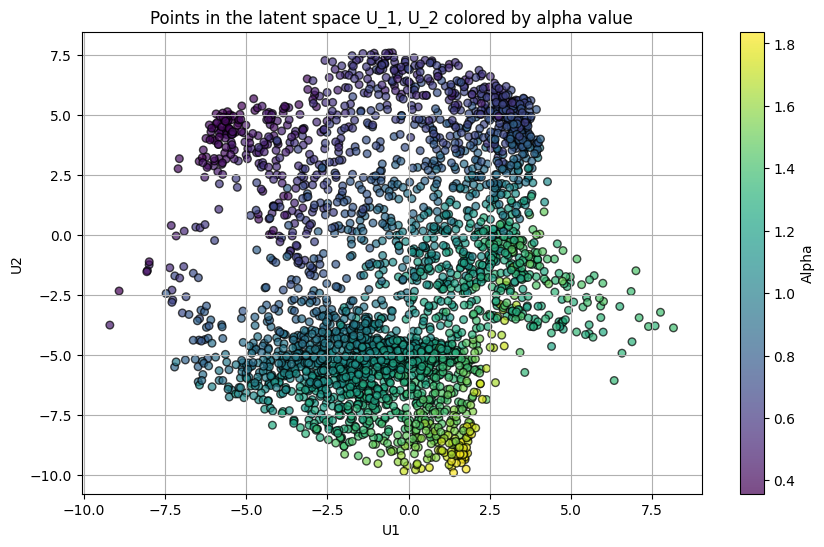

In [ ]:

def load_data(file_path):
    return pd.read_csv(file_path)


def plot_by_alpha(data):
    U1 = data['U_1']
    U2 = data['U_2']
    alpha = data['alpha']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=alpha,cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='Alpha')
    plt.title("Points in the latent space U_1, U_2 colored by alpha value")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

plot_by_alpha(tab2)

def plot_by_best_model(data):
    U1 = data['U_1']
    U2 = data['U_2']
    unique_models = data['best_model'].unique()
    colors = {model: color for model, color in zip(unique_models, plt.cm.Set1.colors)}

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=data['best_model'].map(colors), s=30, edgecolor='k', alpha=0.7)

    legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=model) 
                     for model, color in colors.items()]

    plt.legend(handles=legend_labels, title="Best Model")
    plt.title("Points in the latent space U_1, U_2 colored by 'best-model'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

def plot_by_density(data):
    U1 = data['U_1']
    U2 = data['U_2']
    Density = data['D']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=Density, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='Density')
    plt.title("Points in the latent space U_1, U_2 colored by 'D'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

def plot_by_n_points(data):
    U1 = data['U_1']
    U2 = data['U_2']
    n_points = data['n_points']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=n_points, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='n_points')
    plt.title("Points in the latent space U_1, U_2 colored by n_points")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

def plot_by_log_D(data):
    U1 = data['U_1']
    U2 = data['U_2']
    log_D = data['log_D']

    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(U1, U2, c=log_D, cmap='viridis', s=30, edgecolor='k', alpha=0.7)
    plt.colorbar(scatter, label='log_D')
    plt.title("Points in the latent space U_1, U_2 colored by 'log_D'")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()


### **Clustering with Kmeans: steps of the Algorithm**

**Initialize centroids:**  
Select *k* initial points (randomly or using a method like k-means++) to serve as the centroids of the clusters.

**Assign points to clusters:**  
Each point is assigned to the cluster whose centroid is closest (typically using Euclidean distance).

**Update centroids:**  
For each cluster, recompute the centroid as the mean of all points assigned to it.

**Repeat:**  
Repeat the assignment and update steps until convergence (i.e., centroids no longer change significantly or a maximum number of iterations is reached).

### **Parameter to Evaluate:**

- **k (number of clusters):**  
  This parameter must be chosen in advance.  
  A value of *k* that's too small may merge distinct groups, while a *k* that's too large may over-segment the data.  
  Techniques like the **elbow method** or **silhouette score** can help determine a suitable value for *k*.


### **Finding the Optimum Number of Clusters**

To make sure that K-Means is working efficiently we need to provide them with a starting number of clusters. If the number of clusters is incorrectly selected, the algorithms may not perform well or could take longer to resolve (especially if the number is too high).

We can attempt to identify the optimum number of clusters using an elbow plot, where the goal is to select a number for the clusters based on the 'elbow' or inflection formed in the results. There are other methods such as the silhouette method for picking the number of clusters.

For this example, we will use the elbow plot. To do this we evaluate the model performance over a given range of clusters, and then from the plot identify the most suitable number.

C:\Users\Jeanne\AppData\Local\Temp\ipykernel_11876\2879214673.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(means, inertias, 'o-',linestyle="--",label="Inertie")


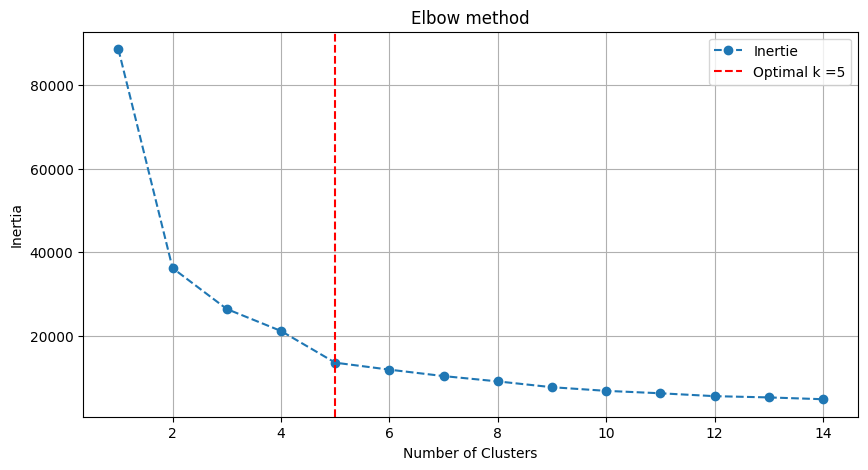

C:\Users\Jeanne\AppData\Local\Temp\ipykernel_11876\2879214673.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(means, inertias, 'o-',linestyle="--",label="Inertie")


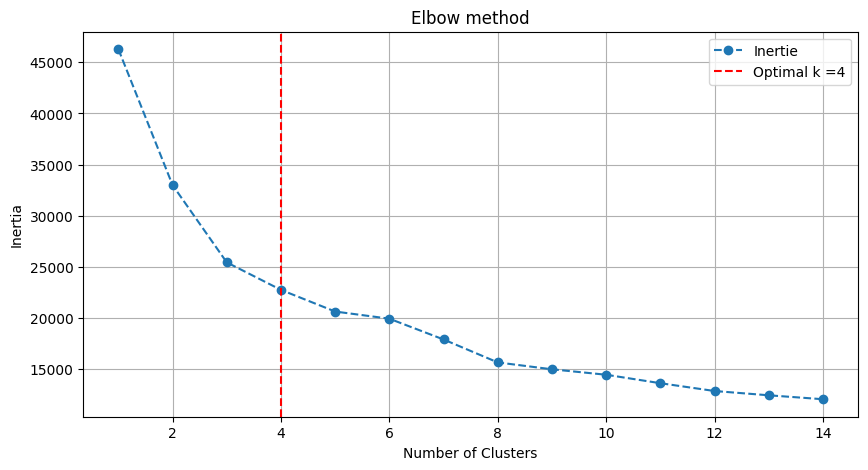

np.int64(4)

In [ ]:
def optimise_k_means(data, max_k,features): #computes k optimal value. features are the column_names of the data on which you want to cluster. 
    """
    optimise_k_means function on the data given in first argument with a maximum number of clusters given as the second argument
    """
    #ex: features = ['U_1','U_2']. As a result, this fonction can be applied on any dimension (16D or 2D). data does not need to be modified before calling optimize_kmeans
    means = []
    inertias = []
    data_selected=data[features]
    
    for k in range(1,max_k):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data_selected)
        means.append(k)
        inertias.append(kmeans.inertia_)
    
    knee_locator= KneeLocator(means,inertias,curve="convex",direction="decreasing")
    optimal_k=knee_locator.knee
        
    fig = plt.subplots(figsize=(10, 5))
    plt.plot(means, inertias, 'o-',linestyle="--",label="Inertie")
    plt.axvline(optimal_k,linestyle="--",color="red",label=f"Optimal k ={optimal_k}")
    plt.xlabel("Number of Clusters")
    plt.ylabel("Inertia")
    plt.title("Elbow method")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return optimal_k #returns the best value for k

optimise_k_means(tab2,15,['U_1','U_2'])
optimise_k_means(tab3,15,['h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16'])

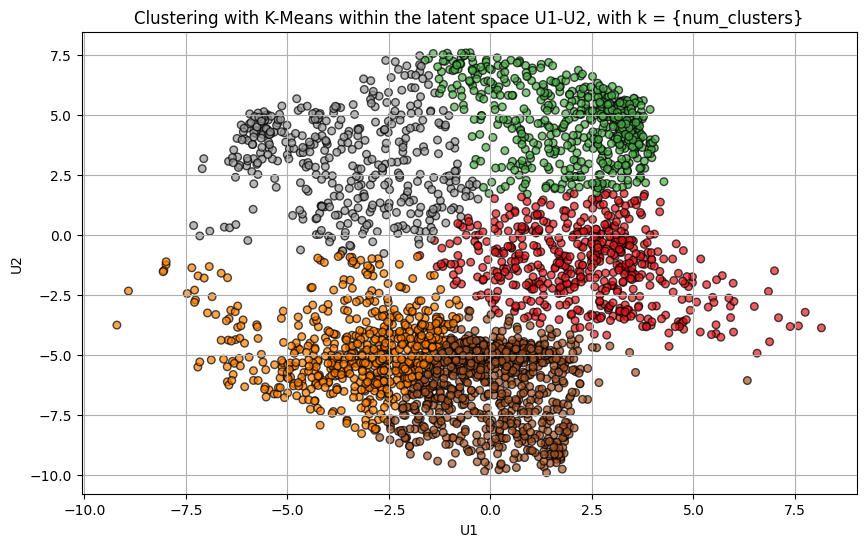

In [ ]:

# Fonction pour réaliser et afficher des clusters, et ajouter une colonne avec l'appartenance pour chaque trajectoire à un cluster
def plot_clusters_kmeans_2D(data, num_clusters):
    U1 = data['U_1']
    U2 = data['U_2']

    kmeans = KMeans(num_clusters, random_state=42)
    clusters = kmeans.fit_predict(data[['U_1', 'U_2']])
    data['KMeans_2D'] = kmeans.labels_
    
    plt.figure(figsize=(10, 6))
    plt.scatter(U1, U2, c=clusters, cmap='Set1', s=30, edgecolor='k', alpha=0.7)

    plt.title("Clustering with K-Means within the latent space U1-U2, with k = {num_clusters}")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

plot_clusters_kmeans_2D(tab2,5)



## Clustering with kmeans in the 16d latent space


C:\Users\Jeanne\AppData\Local\Temp\ipykernel_11876\2879214673.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(means, inertias, 'o-',linestyle="--",label="Inertie")


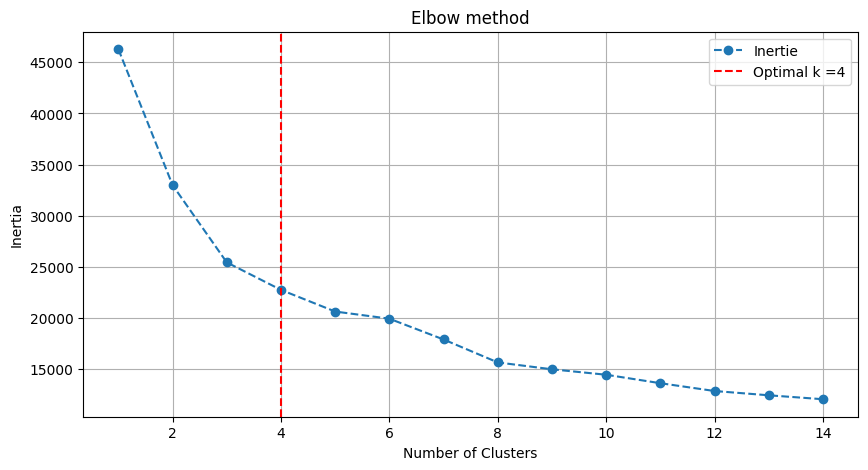

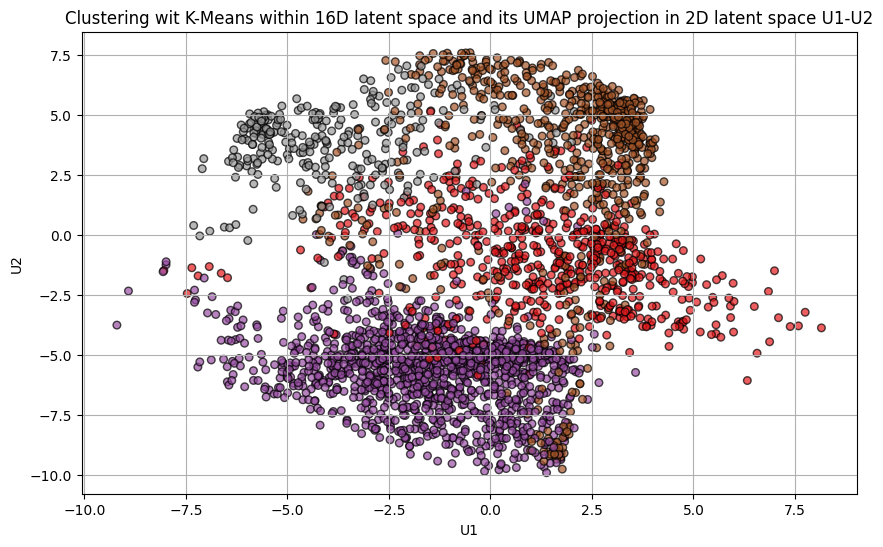

In [ ]:

def plot_clusters_kmeans_16D_in_2D(data, k_max):
    #Find the number of high dimensional clusters
    num_clusters= optimise_k_means(data,k_max,[ 'h_1', 'h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16'])
    
    U1 = data['U_1']
    U2 = data['U_2']

    kmeans = KMeans(num_clusters, random_state=42)
    clusters = kmeans.fit_predict(data[['h_1', 'h_2','h_3','h_4','h_5','h_6','h_7','h_8','h_9','h_10','h_11','h_12','h_13','h_14','h_15','h_16']])
    data['KMeans_16d'] = kmeans.labels_
    plt.figure(figsize=(10, 6))
    plt.scatter(U1, U2, c=clusters, cmap='Set1', s=30, edgecolor='k', alpha=0.7)
    plt.title("Clustering wit K-Means within 16D latent space and its UMAP projection in 2D latent space U1-U2")
    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.grid(True)
    plt.show()

tab=pd.read_csv("gratin_results_for_n2_+myoIb_1_trackedPar.csv")
tab3=selecting_columns_of_interest(tab,['U_1','U_2','best_model','h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16', 'n'])
plot_clusters_kmeans_16D_in_2D(tab3,15)

### Clustering with kmeans and enhancing the density of the computed clusters


c:\Users\Jeanne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
c:\Users\Jeanne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
c:\Users\Jeanne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
c:\Users\Jeanne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KernelDensity was fitted with feature names
  warnings.warn(
c:\Users\Jeanne\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: 

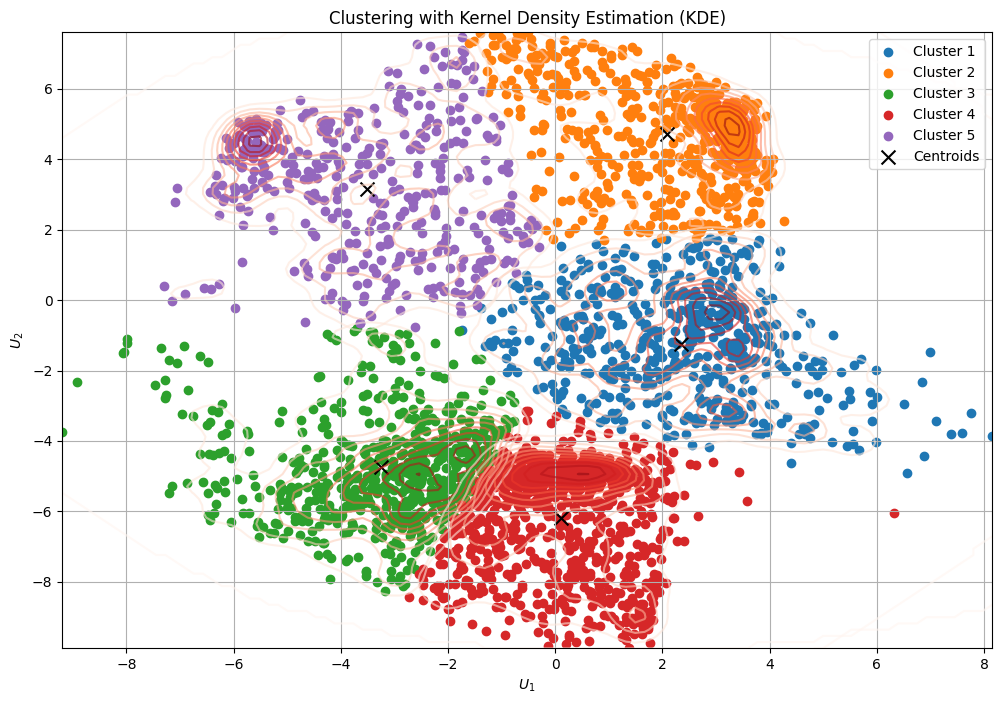

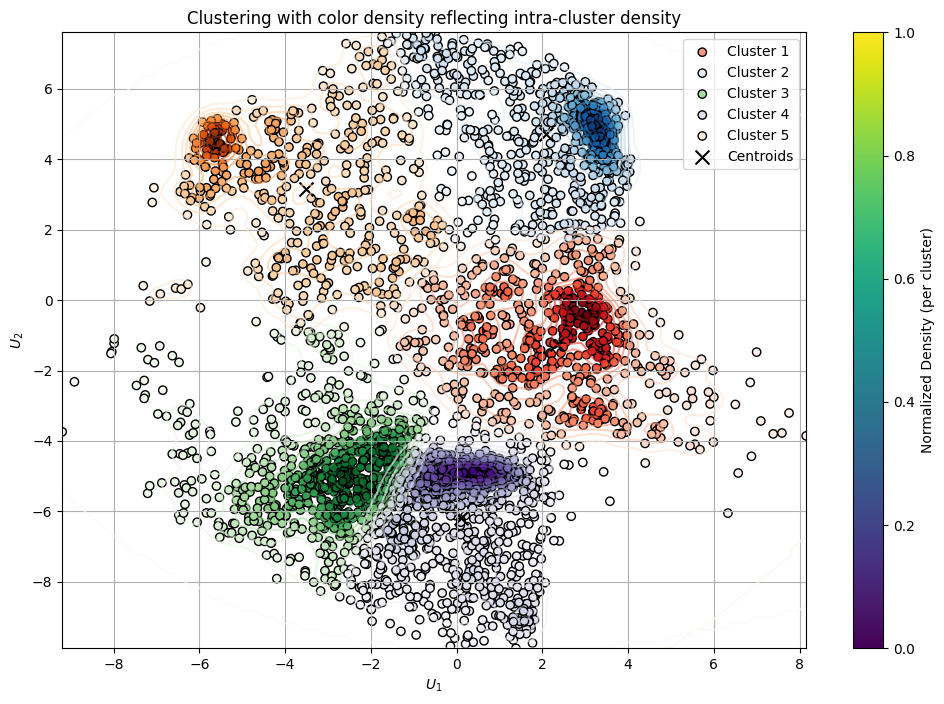

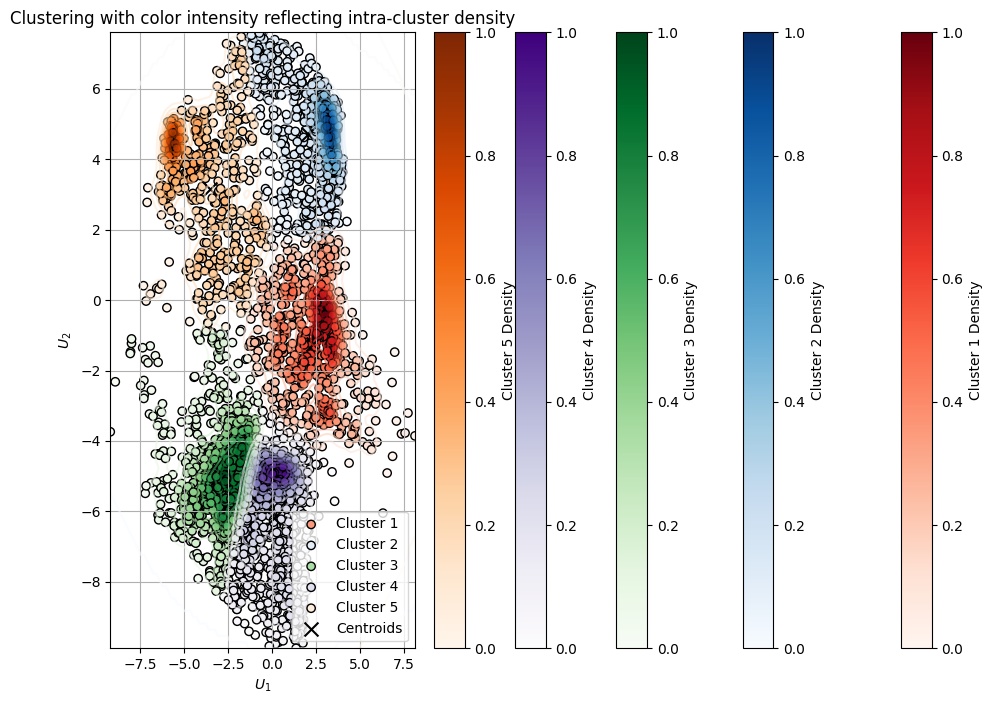

In [ ]:
def clustering_k_means_with_density_2D (data, n_clusters):
    
    u1_u2 = data[['U_1', 'U_2']].dropna()

    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(u1_u2)

    densities = []
    grid_size = 100
    x_min, x_max = u1_u2['U_1'].min(), u1_u2['U_1'].max()
    y_min, y_max = u1_u2['U_2'].min(), u1_u2['U_2'].max()
    x_grid, y_grid = np.meshgrid(
        np.linspace(x_min, x_max, grid_size),
        np.linspace(y_min, y_max, grid_size)
    )
    grid_points = np.vstack([x_grid.ravel(), y_grid.ravel()]).T

    for cluster in range(n_clusters):
        cluster_points = u1_u2[labels == cluster]
        kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
        log_density = kde.score_samples(grid_points)
        densities.append(np.exp(log_density).reshape(grid_size, grid_size))

    plt.figure(figsize=(12, 8))
    for cluster in range(n_clusters):
        cluster_points = u1_u2[labels == cluster]
        plt.scatter(
            cluster_points['U_1'], cluster_points['U_2'], label=f"Cluster {cluster + 1}"
        )
        plt.contour(
            x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap="Reds"
        )

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                color='black', marker='x', label='Centroids', s=100)

    plt.title('Clustering with Kernel Density Estimation (KDE)')
    plt.xlabel('$U_1$')
    plt.ylabel('$U_2$')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12, 8))
    
    color_maps = ['Reds', 'Blues', 'Greens','Purples','Oranges'] 

    for cluster in range(n_clusters):
        cluster_points = u1_u2[labels == cluster].values
        kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
        log_density = kde.score_samples(cluster_points)
        density = np.exp(log_density)
        
        density_norm = (density - density.min()) / (density.max() - density.min())
        
        plt.scatter(
            cluster_points[:, 0], cluster_points[:, 1],
            c=density_norm, cmap=color_maps[cluster], label=f"Cluster {cluster + 1}", edgecolor='k'
        )
        
        plt.contour(
            x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap=color_maps[cluster]
        )

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                color='black', marker='x', label='Centroids', s=100)

    plt.colorbar(label="Normalized Density (per cluster)")
    plt.title('Clustering with color density reflecting intra-cluster density')
    plt.xlabel('$U_1$')
    plt.ylabel('$U_2$')
    plt.legend()
    plt.grid(True)
    plt.show()


    plt.figure(figsize=(12, 8))
    color_maps = ['Reds', 'Blues', 'Greens','Purples','Oranges']  
    for cluster in range(n_clusters):
        cluster_points = u1_u2[labels == cluster].values
        kde = KernelDensity(kernel='gaussian', bandwidth=0.3).fit(cluster_points)
        log_density = kde.score_samples(cluster_points)
        density = np.exp(log_density)
        
        density_norm = (density - density.min()) / (density.max() - density.min())
        
        scatter = plt.scatter(
            cluster_points[:, 0], cluster_points[:, 1],
            c=density_norm, cmap=color_maps[cluster], label=f"Cluster {cluster + 1}", edgecolor='k'
        )
        
        cbar = plt.colorbar(scatter, label=f"Cluster {cluster + 1} Density")
        
        plt.contour(
            x_grid, y_grid, densities[cluster], levels=10, alpha=0.6, cmap=color_maps[cluster]
        )

    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                color='black', marker='x', label='Centroids', s=100)

    plt.title('Clustering with color intensity reflecting intra-cluster density')
    plt.xlabel('$U_1$')
    plt.ylabel('$U_2$')
    plt.legend()
    plt.grid(True)
    plt.show()

clustering_k_means_with_density_2D(tab3,5)

C:\Users\Jeanne\AppData\Local\Temp\ipykernel_11876\1132704895.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_colors = plt.cm.get_cmap('tab10', n_clusters)


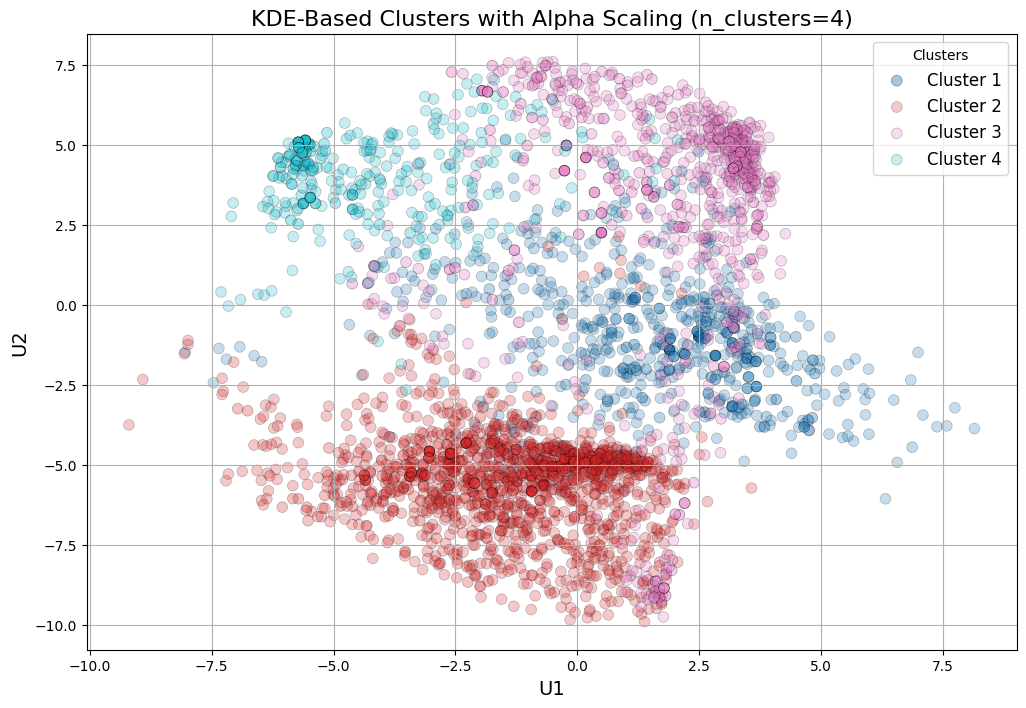

In [ ]:

# Function to plot clusters with KDE and adjusted alpha scaling
def plot_16D_kde_clusters(data, n_clusters, bandwidth=0.5, point_size=60):
    # Extract the 16D features and 2D projection data
    features_16D = data[['h_1', 'h_2', 'h_3', 'h_4', 'h_5', 'h_6', 'h_7', 'h_8',
                          'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14', 'h_15', 'h_16']]
    U1 = data['U_1']
    U2 = data['U_2']
    
    # Perform K-Means clustering on the 16D space
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    clusters = kmeans.fit_predict(features_16D)
    
    # Create a color map for clusters
    cluster_colors = plt.cm.get_cmap('tab10', n_clusters)

    # Initialize the plot
    plt.figure(figsize=(12, 8))
    plt.title(f"KDE-Based Clusters with Alpha Scaling (n_clusters={n_clusters})", fontsize=16)
    plt.xlabel("U1", fontsize=14)
    plt.ylabel("U2", fontsize=14)
    
    # Loop through each cluster to compute KDE and plot
    for cluster_idx in range(n_clusters):
        # Get points belonging to the current cluster
        cluster_points = features_16D[clusters == cluster_idx]
        cluster_U1 = U1[clusters == cluster_idx]
        cluster_U2 = U2[clusters == cluster_idx]
        
        # Compute KDE for the cluster in 16D
        kde = gaussian_kde(cluster_points.T, bw_method=bandwidth)
        cluster_density = kde(cluster_points.T)  # Density values for each point
        
        # Normalize density for alpha scaling (0.25 to 1)
        norm = Normalize(vmin=cluster_density.min(), vmax=cluster_density.max())
        alpha_values = 0.25 + 0.75 * norm(cluster_density)  # Scale to [0.25, 1]
        
        # Plot each point with intensity based on its density
        plt.scatter(cluster_U1, cluster_U2, c=[cluster_colors(cluster_idx)] * len(cluster_U1),
                    alpha=alpha_values, s=point_size, edgecolor='k', linewidth=0.5,
                    label=f"Cluster {cluster_idx + 1}")

    # Add legend and grid
    plt.legend(title="Clusters", loc='best', fontsize=12)
    plt.grid(True)
    plt.show()

plot_16D_kde_clusters(tab3,4)

### Clustering DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

Steps of the Algorithm:

**Identify Core Points:**  
A point is considered a core point if at least *min_samples* points are located within a distance *eps* from it.

**Expand a Cluster:**  
If a core point is found, all points within its *eps* radius become part of the cluster.  
This process is repeated for adjacent core points until no new points can be added.

**Mark Noise:**  
Points that do not belong to any cluster are marked as noise (*Cluster = -1*).

**Two parameters can be evaluated:**

- **eps:**  
  The larger the *eps*, the larger the clusters will be, but it might group together weakly related points.  
  A value that's too small may isolate points that should belong to a cluster.

- **min_samples:**  
  The minimum number of points required for a point to be considered a core point.  
  A high *min_samples* value will only detect very dense clusters.  
  A common choice is *number of dimensions + 1*, to be adjusted based on graphical results and overall context.

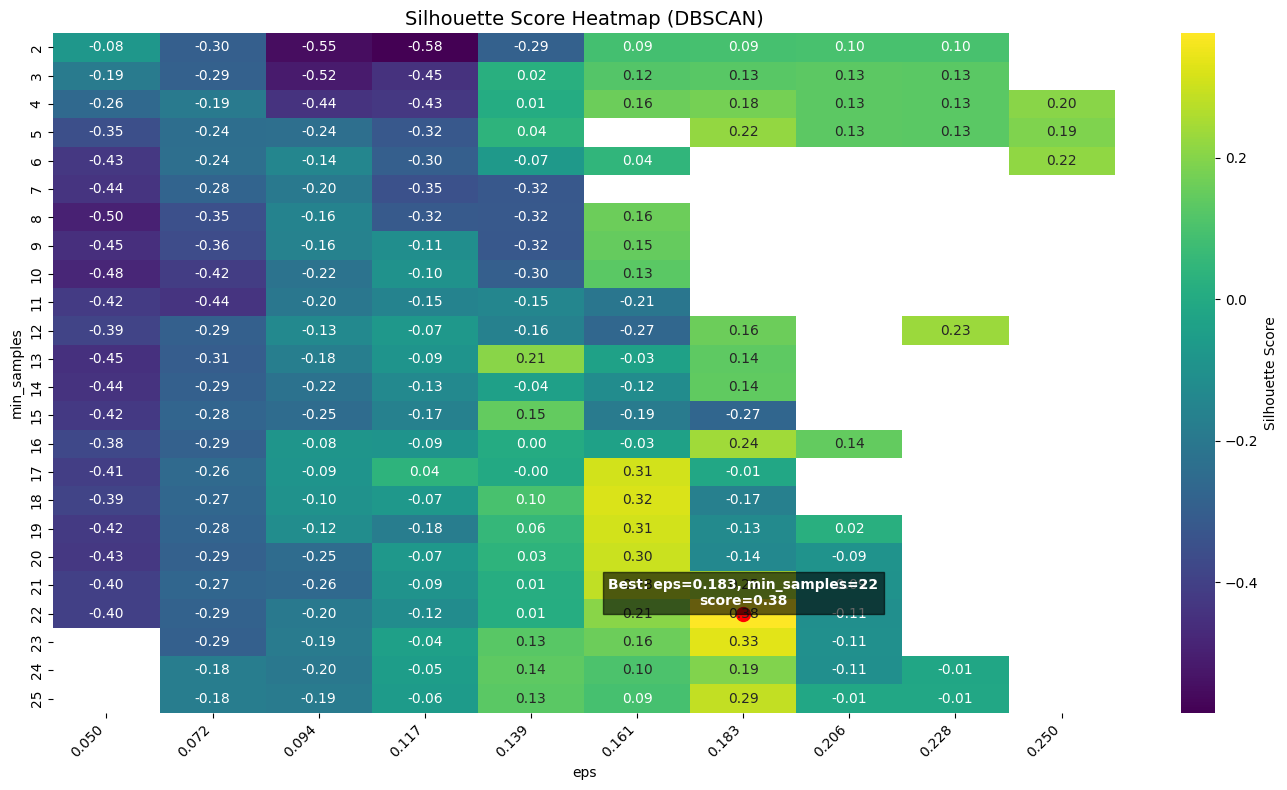

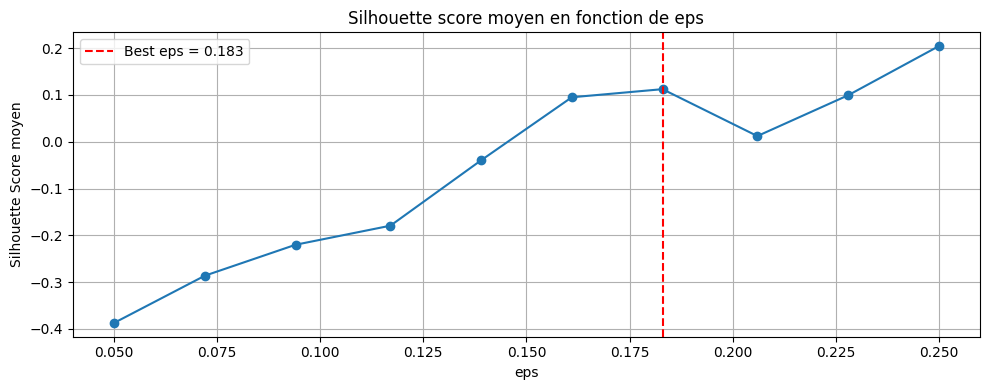

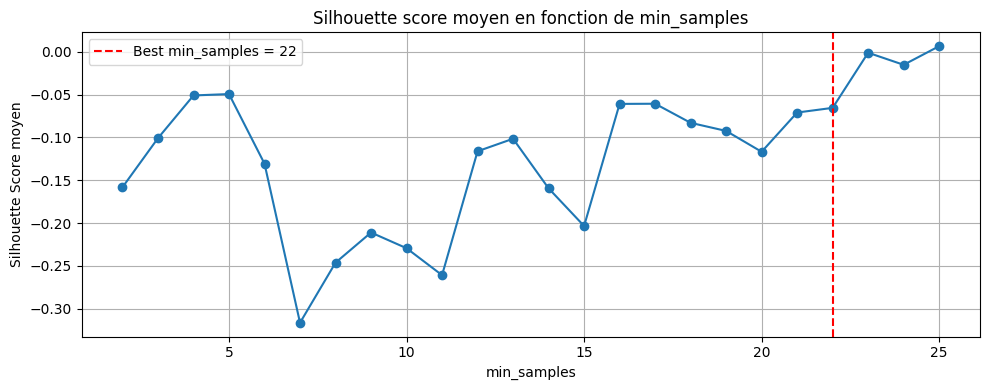

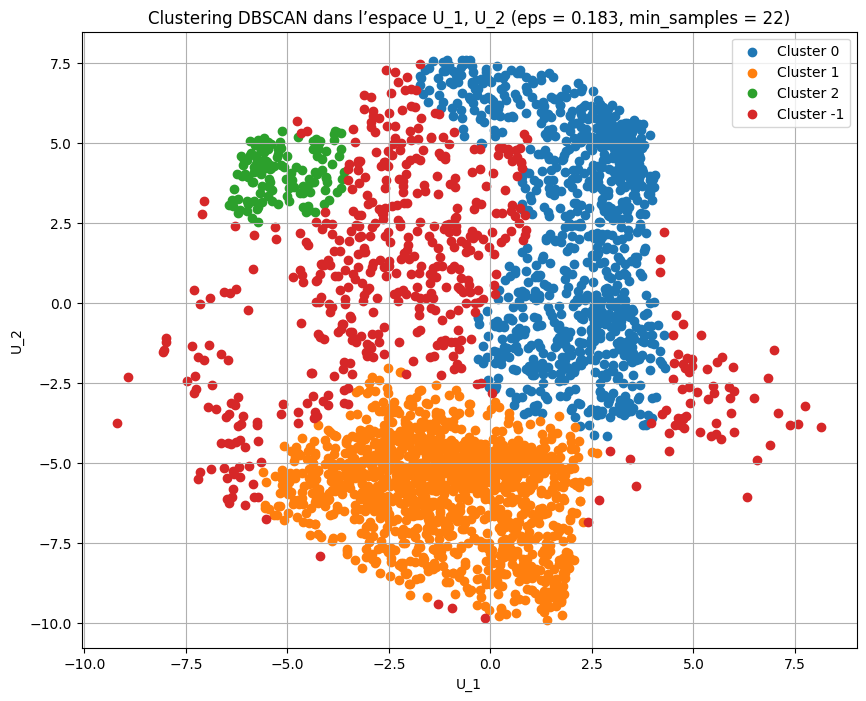

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap_DBSCAN_2D(data, eps_range=(0.05, 0.25, 10), min_samples_range=(2, 26)):
    data = data[['U_1', 'U_2']].dropna()
    scaled_data = StandardScaler().fit_transform(data)

    eps_values = np.round(np.linspace(eps_range[0], eps_range[1], eps_range[2]), 3)
    min_samples_values = list(range(min_samples_range[0], min_samples_range[1]))

    score_matrix = np.full((len(min_samples_values), len(eps_values)), np.nan)

    for i, min_samples in enumerate(min_samples_values):
        for j, eps in enumerate(eps_values):
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(scaled_data)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters > 1:
                score = silhouette_score(scaled_data, labels)
                score_matrix[i, j] = score

    best_idx = np.unravel_index(np.nanargmax(score_matrix), score_matrix.shape)
    best_min_samples = min_samples_values[best_idx[0]]
    best_eps = eps_values[best_idx[1]]
    best_score = score_matrix[best_idx]

    plt.figure(figsize=(14, 8))
    ax = sns.heatmap(score_matrix,
                     xticklabels=[f"{e:.3f}" for e in eps_values],
                     yticklabels=min_samples_values,
                     cmap="viridis", annot=True, fmt=".2f",
                     cbar_kws={'label': 'Silhouette Score'})

    ax.plot(best_idx[1] + 0.5, best_idx[0] + 0.5, 'ro', markersize=10)
    ax.text(best_idx[1] + 0.5, best_idx[0] + 0.3,
            f"Best: eps={best_eps}, min_samples={best_min_samples}\nscore={best_score:.2f}",
            color='white', ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6))

    plt.title("Silhouette Score Heatmap (DBSCAN)", fontsize=14)
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    mean_scores_per_eps = np.nanmean(score_matrix, axis=0)
    plt.figure(figsize=(10, 4))
    plt.plot(eps_values, mean_scores_per_eps, marker='o')
    plt.axvline(best_eps, color='red', linestyle='--', label=f"Best eps = {best_eps}")
    plt.title("Average silhouette score for every eps")
    plt.xlabel("eps")
    plt.ylabel("Average Silhouette Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    mean_scores_per_min_samples = np.nanmean(score_matrix, axis=1)
    plt.figure(figsize=(10, 4))
    plt.plot(min_samples_values, mean_scores_per_min_samples, marker='o')
    plt.axvline(best_min_samples, color='red', linestyle='--', label=f"Best min_samples = {best_min_samples}")
    plt.title("Average silhouette score for every min_samples")
    plt.xlabel("min_samples")
    plt.ylabel("Average Silhouette Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return best_eps, best_min_samples

def clustering_DBSCAN_2D(data, eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    u1_u2 = data[['U_1', 'U_2']].dropna()

    scaler = StandardScaler()
    u1_u2_scaled = scaler.fit_transform(u1_u2)
    clusters = dbscan.fit_predict(u1_u2_scaled)

    u1_u2['Cluster'] = clusters
    data['Cluster_DB_scan_2D'] = clusters

    plt.figure(figsize=(10, 8))
    for cluster in set(clusters):
        cluster_points = u1_u2[u1_u2['Cluster'] == cluster]
        plt.scatter(cluster_points['U_1'], cluster_points['U_2'], label=f'Cluster {cluster}')

    plt.title(f'Clustering DBSCAN in the latent space U_1, U_2 (eps = {eps:.3f}, min_samples = {min_samples})')
    plt.xlabel('U_1')
    plt.ylabel('U_2')
    plt.legend()
    plt.grid()
    plt.show()


#test
tab=pd.read_csv("gratin_results_for_n2_+myoIb_1_trackedPar.csv")
tab3=selecting_columns_of_interest(tab,['best_model','h_1', 'h_2', 'h_3', 'h_4', 'h_5',
       'h_6', 'h_7', 'h_8', 'h_9', 'h_10', 'h_11', 'h_12', 'h_13', 'h_14',
       'h_15', 'h_16', 'n','U_1','U_2'])
best_eps,best_min_samples=heatmap_DBSCAN_2D(tab3)
clustering_DBSCAN_2D(tab3,best_eps,best_min_samples)

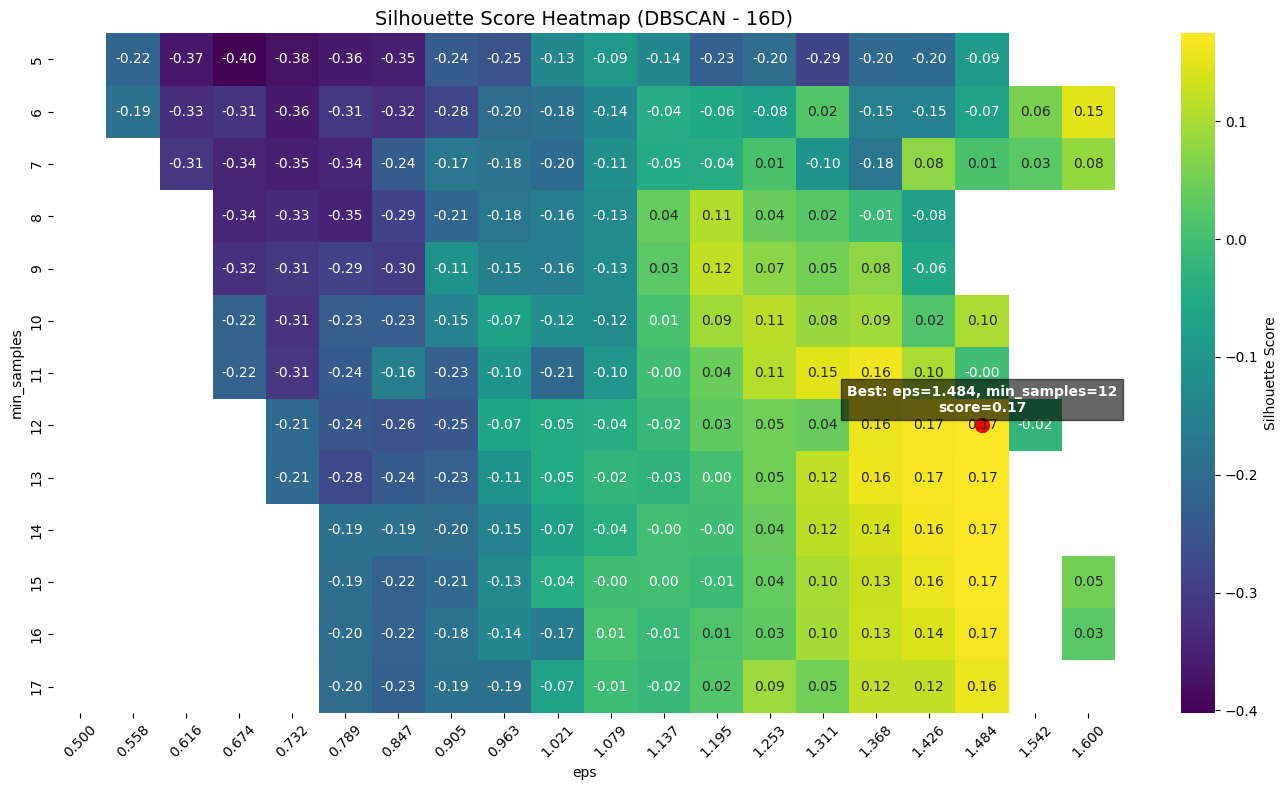

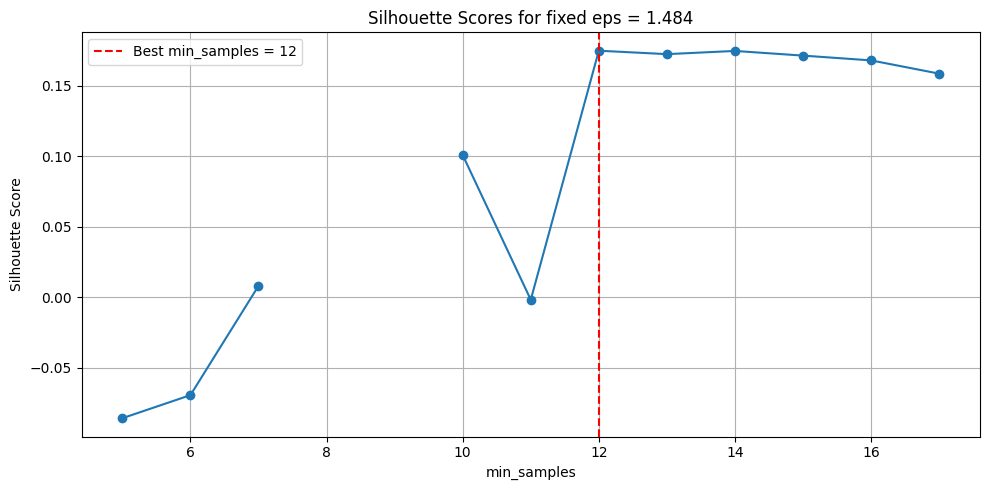

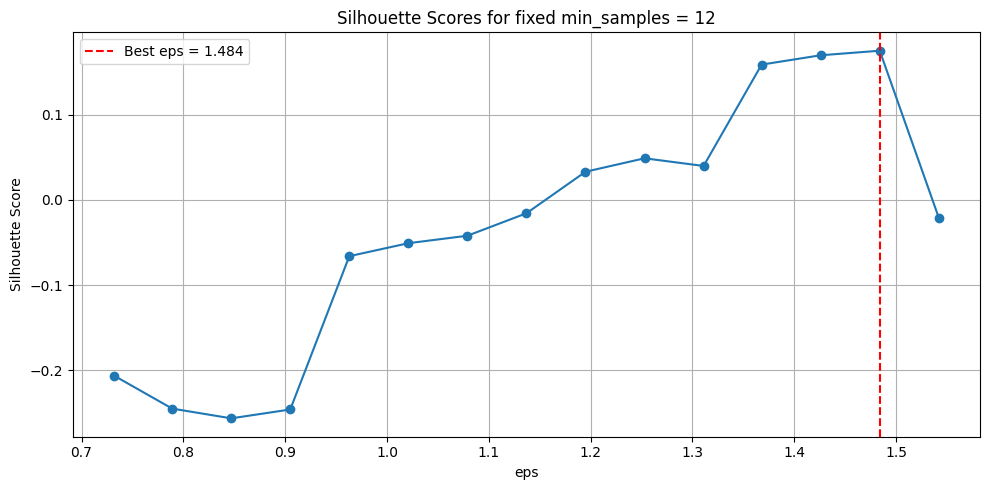

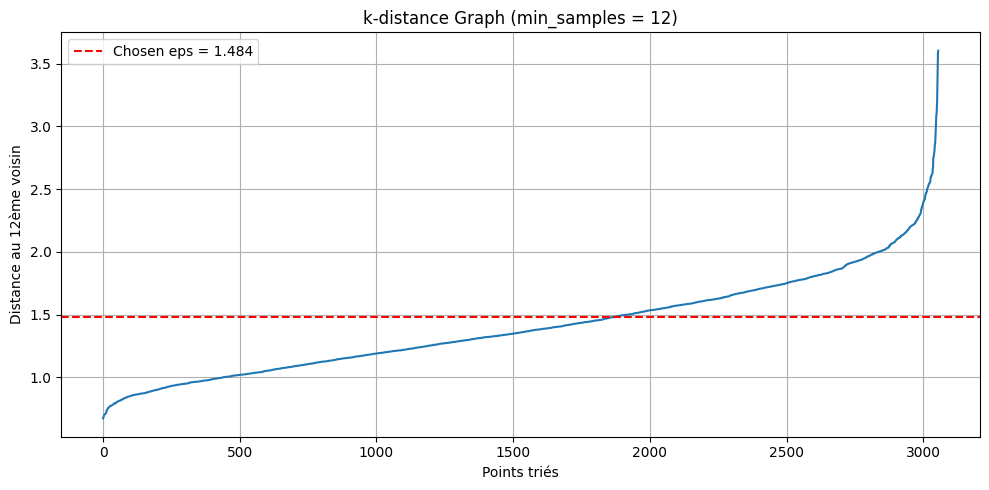

les meilleurs couples (min_samples,eps) sont:


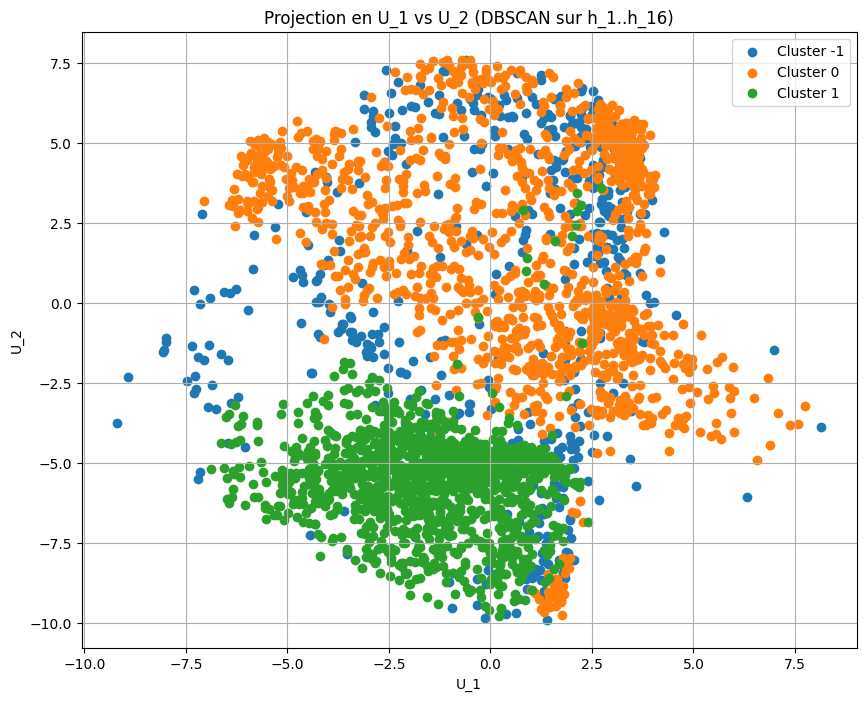

In [ ]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

def heatmap_DBSCAN_16D(data, eps_range=(0.5, 1.6, 20), min_samples_range=(5, 18)):
    features = [f'h_{i}' for i in range(1, 17)]
    data_16D = data[features].dropna()
    scaled_data = StandardScaler().fit_transform(data_16D)

    # Grille des eps
    eps_values = np.round(np.linspace(*eps_range), 3)
    min_samples_values = list(range(*min_samples_range))

    score_matrix = np.full((len(min_samples_values), len(eps_values)), np.nan)

    for i, min_samples in enumerate(min_samples_values):
        for j, eps in enumerate(eps_values):
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(scaled_data)
            unique_labels = set(labels)
            if -1 in unique_labels:
                unique_labels.remove(-1)

            if len(unique_labels) >= 2:
                score = silhouette_score(scaled_data, labels)
                score_matrix[i, j] = score

    best_score = np.nanmax(score_matrix)
    best_positions = np.argwhere(score_matrix == best_score)
    sorted_best = sorted(best_positions, key=lambda x: (x[0], x[1]))  # min_samples puis eps croissants

    best_parameters = [ 
    (min_samples_values[i], eps_values[j]) 
    for i, j in sorted_best 
    ]
    best_min_samples, best_eps = best_parameters[0]  # Choix par défaut : le premier

    best_i,best_j=sorted_best[0]
    # 🔥 Heatmap des scores silhouette
    plt.figure(figsize=(14, 8))
    ax = sns.heatmap(score_matrix,
                     xticklabels=[f"{e:.3f}" for e in eps_values],
                     yticklabels=min_samples_values,
                     cmap="viridis", annot=True, fmt=".2f",
                     cbar_kws={'label': 'Silhouette Score'})
    ax.plot(best_j + 0.5, best_i + 0.5, 'ro', markersize=10)
    ax.text(best_j + 0.5, best_i + 0.3,
            f"Best: eps={best_eps}, min_samples={best_min_samples}\nscore={best_score:.2f}",
            color='white', ha='center', va='bottom', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.6))
    plt.title("Silhouette Score Heatmap (DBSCAN - 16D)", fontsize=14)
    plt.xlabel("eps")
    plt.ylabel("min_samples")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # 📈 Tracé du silhouette score pour eps optimal
    silhouette_scores_eps_fixed = []
    for min_samples in min_samples_values:
        db = DBSCAN(eps=best_eps, min_samples=min_samples)
        labels = db.fit_predict(scaled_data)
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) >= 2:
            score = silhouette_score(scaled_data, labels)
            silhouette_scores_eps_fixed.append(score)
        else:
            silhouette_scores_eps_fixed.append(np.nan)

    plt.figure(figsize=(10, 5))
    plt.plot(min_samples_values, silhouette_scores_eps_fixed, marker='o')
    plt.axvline(x=best_min_samples, color='red', linestyle='--', label=f'Best min_samples = {best_min_samples}')
    plt.title(f'Silhouette Scores for fixed eps = {best_eps:.3f}')
    plt.xlabel('min_samples')
    plt.ylabel('Silhouette Score')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    silhouette_scores_eps_fixed = []
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=best_min_samples)
        labels = db.fit_predict(scaled_data)
        unique_labels = set(labels)
        if -1 in unique_labels:
            unique_labels.remove(-1)
        if len(unique_labels) >= 2:
            score = silhouette_score(scaled_data, labels)
            silhouette_scores_eps_fixed.append(score)
        else:
            silhouette_scores_eps_fixed.append(np.nan)

    plt.figure(figsize=(10, 5))
    plt.plot(eps_values, silhouette_scores_eps_fixed, marker='o')
    plt.axvline(x=best_eps, color='red', linestyle='--', label=f'Best eps = {best_eps}')
    plt.title(f'Silhouette Scores for fixed min_samples = {best_min_samples}')
    plt.xlabel('eps')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


    # 📉 Méthode du coude : k-distance plot
    neighbors = NearestNeighbors(n_neighbors=best_min_samples).fit(scaled_data)
    distances, indices = neighbors.kneighbors(scaled_data)
    k_distances = np.sort(distances[:, -1])  # dernière colonne = distance au k-ième plus proche voisin

    plt.figure(figsize=(10, 5))
    plt.plot(k_distances)
    plt.axhline(y=best_eps, color='red', linestyle='--', label=f'Chosen eps = {best_eps:.3f}')
    plt.title(f'k-distance Graph (min_samples = {best_min_samples})')
    plt.xlabel('Sorted points')
    plt.ylabel(f'Distance at the {best_min_samples}th neighbor')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("the best couples of parameters (min_samples,eps) are:")
    print(best_parameters)
    return best_eps, best_min_samples


def clustering_projection_U1_U2(data, eps, min_samples):
    features = [f'h_{i}' for i in range(1, 17)]
    df = data.copy()
    u1_u2 = df[['U_1', 'U_2']].dropna()
    data_16D = df[features].dropna()

    # Standardiser les features
    scaled_16D = StandardScaler().fit_transform(data_16D)
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(scaled_16D)

    # Injecte les clusters dans le dataframe d’origine
    df = df.loc[data_16D.index]
    df['Cluster_DB_16D'] = labels

    u1_u2 = df[['U_1', 'U_2', 'Cluster_DB_16D']]

    # 🔎 Visualisation
    plt.figure(figsize=(10, 8))
    for label in sorted(u1_u2['Cluster_DB_16D'].unique()):
        cluster_data = u1_u2[u1_u2['Cluster_DB_16D'] == label]
        plt.scatter(cluster_data['U_1'], cluster_data['U_2'], label=f'Cluster {label}')
    plt.title(f'Projection on (U_1,U_2) of DBSCAN 16D)')
    plt.xlabel('U_1')
    plt.ylabel('U_2')
    plt.legend()
    plt.grid()
    plt.show()


# Chargement des données
tab = pd.read_csv("gratin_results_for_n2_+myoIb_1_trackedPar.csv")
tab3 = selecting_columns_of_interest(tab, [
    'best_model', 'U_1', 'U_2', 'n',
    *[f'h_{i}' for i in range(1, 17)]
])

# Recherche des meilleurs paramètres en 16D
best_eps, best_min_samples = heatmap_DBSCAN_16D(tab3)

# Affichage des clusters projetés sur U_1, U_2
clustering_projection_U1_U2(tab3, best_eps, best_min_samples)



### Machine learning on axone-synapse location

The idea is to see if there is a correlation between the location of the trajectory in the axone or in the synapse and its position within the latent space.

In [ ]:
def create_file_axon_synapse (locs_path,results_path, output_path):   
    
    # Read CSV files
    gratin_results = pd.read_csv(results_path)
    locs_data = pd.read_csv(locs_path)

    locs_subset = locs_data[['n', 'on_axon', 'on_synapse']]

    locs_subset = locs_subset.drop_duplicates(subset='n')


    merged_data = gratin_results.merge(locs_subset, on='n', how='left')

    merged_data.to_csv(output_path, index=False)

    print(f"The updated file has been saved as: '{output_path}'")

In [ ]:
def learn_axon_synapse (file_path):
    df = pd.read_csv(file_path)
    
    def assign_color(row):
        if row['on_axon'] and row['on_synapse']:
            return 'purple'  # Les deux actifs
        elif row['on_axon']:
            return 'red'  # Seulement is_axon
        elif row['on_synapse']:
            return 'blue'  # Seulement is_synapse
        else:
            return 'gray'  # Aucun actif

    df['color'] = df.apply(assign_color, axis=1)

    
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df['U_1'], y=df['U_2'], hue=df['color'], palette={'red': 'red', 'blue': 'blue', 'purple': 'purple', 'gray': 'gray'}, legend=False)

    
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(color='red', label='Axon'),
        mpatches.Patch(color='blue', label='Synapse'),
        mpatches.Patch(color='purple', label='Les deux'),
        mpatches.Patch(color='gray', label='Aucun')
    ]
    plt.legend(handles=legend_patches, title="Type")

    plt.xlabel("U1")
    plt.ylabel("U2")
    plt.title("Trajectories reprenstation within the latent space U1-U2")

the following code aims to cut in little segments the considered trajectories not to make any difference between axone and synapse


In [ ]:

def segment_trajectories_between_axon_and_synapse(file_path):
    df=pd.read_csv(file_path)
    #new_data = df.sort_values(by=["n","frame"])
    #print(new_data.head(n=20))
    new_df = pd.DataFrame(columns=df.columns)
    cpt_traj = 0
    for n in range(int(df['n'].max()) + 1):
    #for n in range(10000):
        selected_rows = df[df['n'] == n]
        selected_rows=selected_rows.reset_index(drop=True)
        if len(selected_rows)>5:
            #print(selected_rows)
            #print(selected_rows.loc[0])
            selected_rows.at[0, 'n'] = cpt_traj
            #print(n,cpt_traj)
            new_df = pd.concat([new_df, selected_rows.iloc[[0]]], ignore_index=True)
            s=selected_rows.loc[0]['on_synapse']
            a=selected_rows.loc[0]['on_axon']
            j=1
            while j < len(selected_rows):
                while j < len(selected_rows) and selected_rows.loc[j, 'on_synapse'] == s and selected_rows.loc[j, 'on_axon'] == a:
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    j+=1
                cpt_traj+=1
                if j < len(selected_rows):
                    selected_rows.at[j, 'n'] = cpt_traj
                    new_df = pd.concat([new_df, selected_rows.iloc[[j]]], ignore_index=True)
                    s=selected_rows.loc[j]['on_synapse']
                    a=selected_rows.loc[j]['on_axon']
                    j+=1
    print(new_df.head(n=20))
    return new_df
                    
            
new_data = segment_trajectories_between_axon_and_synapse(file_path)          
output_path = file_path.split('.locs')[0]+"_segmented_trajectories.csv"
new_data.to_csv(output_path)#, index=False)
print(output_path)


NameError: name 'file_path' is not defined